<a href="https://colab.research.google.com/github/Pankhuritrivedi01/DTI-Lab/blob/main/project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

df = pd.read_csv(
    "building_consumption.csv",
    on_bad_lines="skip"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (3283779, 4)
  campus_id  meter_id            timestamp  consumption
0         1       1.0  2019-03-29 01:15:00        0.011
1         1       1.0  2019-03-29 01:30:00        0.021
2         1       1.0  2019-03-29 01:45:00        0.038
3         1       1.0  2019-03-29 02:00:00        0.871
4         1       1.0  2019-03-29 02:15:00        0.873
['campus_id', 'meter_id', 'timestamp', 'consumption']


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of rows: 3283779
Number of columns: 4

Column Names:
['campus_id', 'meter_id', 'timestamp', 'consumption']


In [5]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3283779 entries, 0 to 3283778
Data columns (total 4 columns):
 #   Column       Dtype  
---  ------       -----  
 0   campus_id    object 
 1   meter_id     float64
 2   timestamp    object 
 3   consumption  float64
dtypes: float64(2), object(2)
memory usage: 100.2+ MB


In [6]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,meter_id,consumption
count,3.283779e+06,3.283776e+06
mean,2.242258e+01,1.238601e+01
std,7.760295e+00,1.174678e+01
min,1.000000e+00,-2.279800e+01
25%,1.700000e+01,2.859380e+00
50%,2.300000e+01,9.375000e+00
75%,2.900000e+01,1.800000e+01
max,3.400000e+01,7.944050e+01


In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
campus_id      0
meter_id       0
timestamp      1
consumption    3
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

campus_id      0.000000
meter_id       0.000000
timestamp      0.000030
consumption    0.000091
dtype: float64


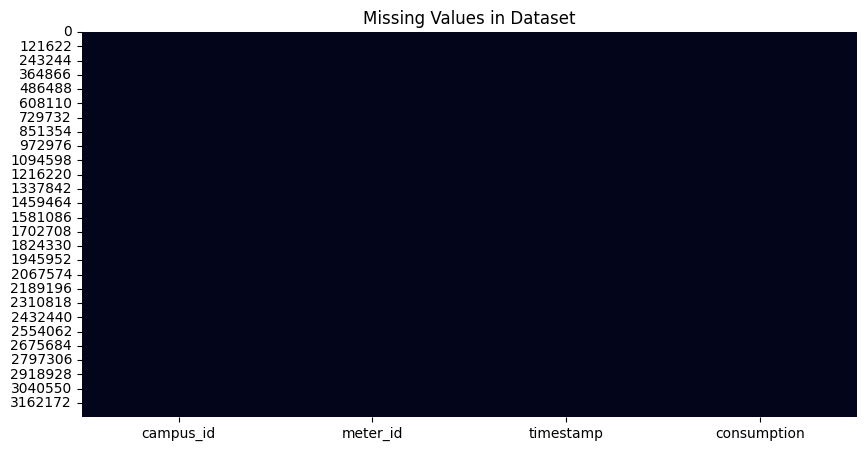

In [9]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Dataset")
plt.show()

In [10]:
print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates before removal: 0
Duplicates after removal: 0


In [11]:
print(df.columns.tolist())

['campus_id', 'meter_id', 'timestamp', 'consumption']


In [12]:
df.head(10)

,campus_id,meter_id,timestamp,consumption
0,1,1.0,2019-03-29 01:15:00,0.011
1,1,1.0,2019-03-29 01:30:00,0.021
2,1,1.0,2019-03-29 01:45:00,0.038
3,1,1.0,2019-03-29 02:00:00,0.871
4,1,1.0,2019-03-29 02:15:00,0.873
5,1,1.0,2019-03-29 02:30:00,0.876
6,1,1.0,2019-03-29 02:45:00,0.875
7,1,1.0,2019-03-29 03:00:00,0.872
8,1,1.0,2019-03-29 03:15:00,0.872
9,1,1.0,2019-03-29 03:30:00,0.872


In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [14]:
print(df.columns)

Index(['campus_id', 'meter_id', 'timestamp', 'consumption'], dtype='object')


In [15]:
print(df['timestamp'].head())
print(df['timestamp'].dtype)

0   2019-03-29 01:15:00
1   2019-03-29 01:30:00
2   2019-03-29 01:45:00
3   2019-03-29 02:00:00
4   2019-03-29 02:15:00
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]


In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [17]:
print(df.isnull().sum())

campus_id      0
meter_id       0
timestamp      7
consumption    0
dtype: int64


In [18]:
df['Year'] = df['timestamp'].dt.year
df['Month'] = df['timestamp'].dt.month
df['Day'] = df['timestamp'].dt.day
df['Hour'] = df['timestamp'].dt.hour
df['DayOfWeek'] = df['timestamp'].dt.dayofweek

In [19]:
df[['timestamp', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']].head()

,timestamp,Year,Month,Day,Hour,DayOfWeek
0,2019-03-29 01:15:00,2019.0,3.0,29.0,1.0,4.0
1,2019-03-29 01:30:00,2019.0,3.0,29.0,1.0,4.0
2,2019-03-29 01:45:00,2019.0,3.0,29.0,1.0,4.0
3,2019-03-29 02:00:00,2019.0,3.0,29.0,2.0,4.0
4,2019-03-29 02:15:00,2019.0,3.0,29.0,2.0,4.0


In [20]:
df['DayType'] = df['DayOfWeek'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

df[['timestamp', 'DayOfWeek', 'DayType']].head()

,timestamp,DayOfWeek,DayType
0,2019-03-29 01:15:00,4.0,Weekday
1,2019-03-29 01:30:00,4.0,Weekday
2,2019-03-29 01:45:00,4.0,Weekday
3,2019-03-29 02:00:00,4.0,Weekday
4,2019-03-29 02:15:00,4.0,Weekday


In [21]:
print(df.columns.tolist())

['campus_id', 'meter_id', 'timestamp', 'consumption', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayType']


In [22]:
consumption_column = 'consumption'

In [24]:
print("Average electricity consumption:",
      df[consumption_column].mean())

print("Maximum electricity consumption:",
      df[consumption_column].max())

print("Minimum electricity consumption:",
      df[consumption_column].min())

print("Standard deviation:",
      df[consumption_column].std())

Average electricity consumption: 12.386004226676025
Maximum electricity consumption: 79.4405
Minimum electricity consumption: -22.798
Standard deviation: 11.74677910492273


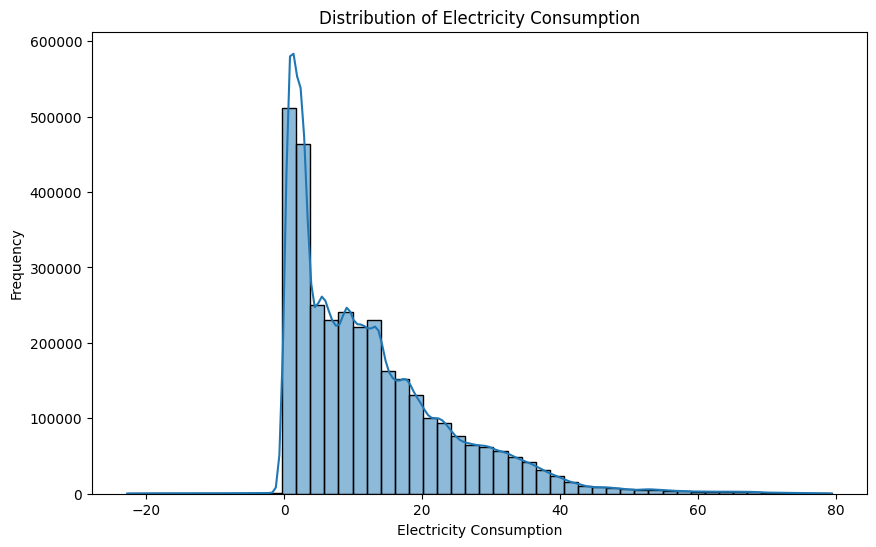

In [25]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df[consumption_column],
    bins=50,
    kde=True
)

plt.xlabel("Electricity Consumption")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Consumption")

plt.show()

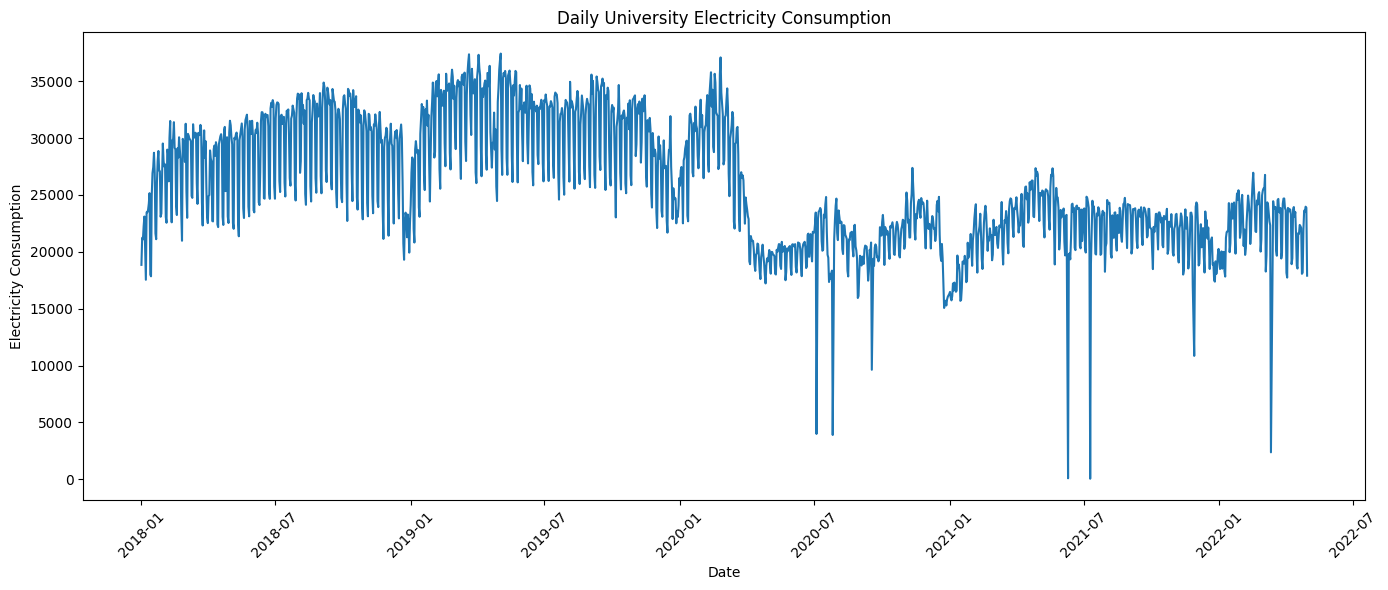

In [26]:
daily_consumption = df.groupby(
    df['timestamp'].dt.date
)[consumption_column].sum()

plt.figure(figsize=(14, 6))

plt.plot(
    daily_consumption.index,
    daily_consumption.values
)

plt.xlabel("Date")
plt.ylabel("Electricity Consumption")
plt.title("Daily University Electricity Consumption")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
hourly_consumption = df.groupby(
    'Hour'
)[consumption_column].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_consumption.index,
    hourly_consumption.values,
    marker='o'
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Electricity Consumption")
plt.title("Average Electricity Consumption by Hour")

plt.grid(True)

plt.show()

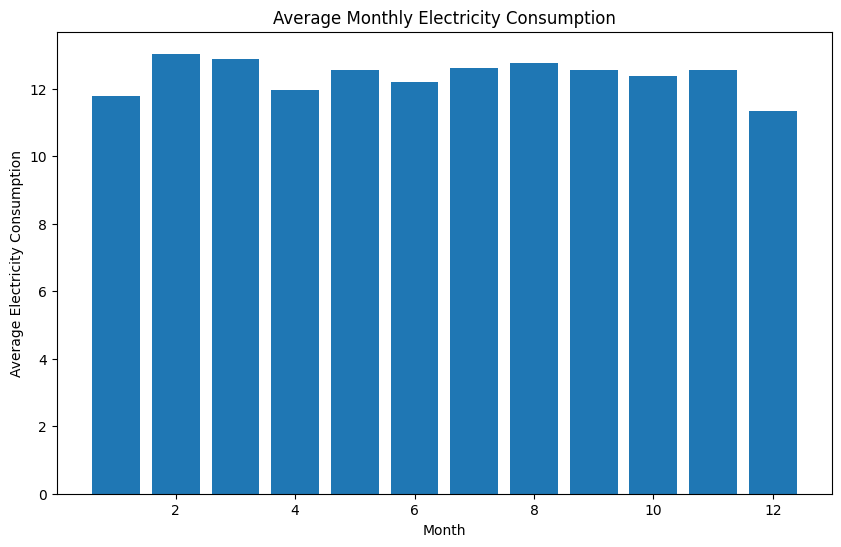

In [27]:
monthly_consumption = df.groupby(
    'Month'
)[consumption_column].mean()

plt.figure(figsize=(10, 6))

plt.bar(
    monthly_consumption.index,
    monthly_consumption.values
)

plt.xlabel("Month")
plt.ylabel("Average Electricity Consumption")
plt.title("Average Monthly Electricity Consumption")

plt.show()

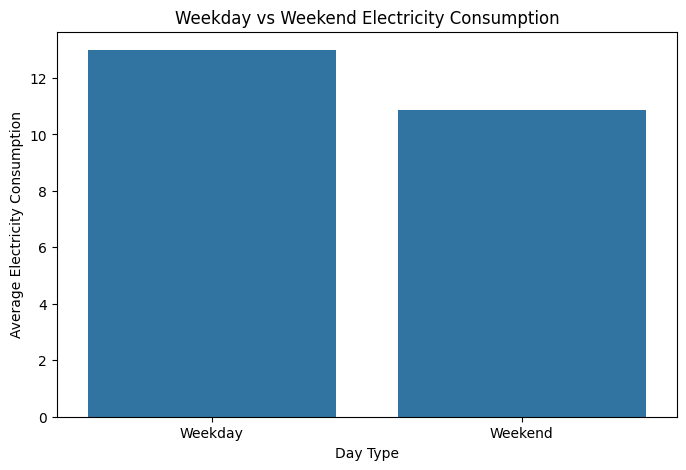

In [28]:
day_consumption = df.groupby(
    'DayType'
)[consumption_column].mean()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=day_consumption.index,
    y=day_consumption.values
)

plt.xlabel("Day Type")
plt.ylabel("Average Electricity Consumption")
plt.title("Weekday vs Weekend Electricity Consumption")

plt.show()

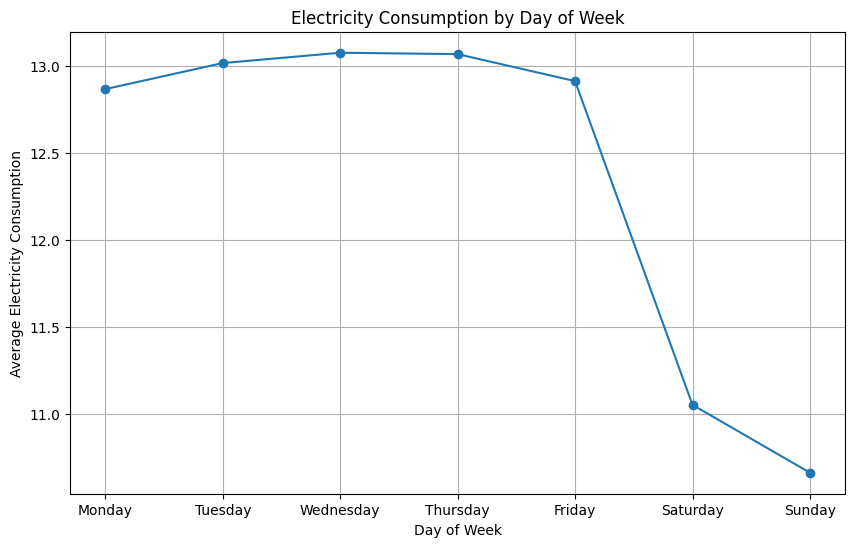

In [29]:
weekday_consumption = df.groupby(
    'DayOfWeek'
)[consumption_column].mean()

plt.figure(figsize=(10, 6))

plt.plot(
    weekday_consumption.index,
    weekday_consumption.values,
    marker='o'
)

plt.xlabel("Day of Week")
plt.ylabel("Average Electricity Consumption")
plt.title("Electricity Consumption by Day of Week")

plt.xticks(
    range(7),
    ['Monday', 'Tuesday', 'Wednesday',
     'Thursday', 'Friday', 'Saturday', 'Sunday']
)

plt.grid(True)

plt.show()

In [31]:
building_consumption = df.groupby(
    'building_id'
)[consumption_column].mean().sort_values(ascending=False)

print(building_consumption.head(10))

KeyError: 'building_id'